# Tekstdetektion på Chest X-Ray billeder (OpenCV + pytesseract)

Denne notebook scanner chest X-ray billeder for tekst/bogstaver ved hjælp af **OpenCV** til billedbehandling og **pytesseract** (Tesseract OCR) til tegngenkendelse.

**Hvad den gør:**
- Indlæser et røntgenbillede
- Forbehandler billedet (thresholding, denoising) til bedre OCR-nøjagtighed
- Detekterer bogstaver/tekst med pytesseract
- Tæller antallet af tegn og ord
- Tegner bounding boxes rundt om fundne tekstregioner

In [13]:
# Installer nødvendige pakker (kør én gang)
# pip install opencv-python pytesseract pillow matplotlib numpy
# OBS: Tesseract-binær skal også installeres på systemet:
#   Windows: https://github.com/UB-Mannheim/tesseract/wiki
#   Sæt stien nedenfor hvis det ikke er på PATH

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["opencv-python", "pytesseract", "pillow", "matplotlib", "numpy"]:
    install(pkg)

print("Pakker installeret ✓")

Pakker installeret ✓


In [14]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

#--- Sti til Tesseract (Windows) ---
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

#--- Sæt stien til et enkelt X-ray billede her ---
IMAGE_PATH = r"..\..\billeder\chest_xray\NORMAL\IM-0001-0001.jpeg" # <-- SKIFT EFTER BEHOV


print("Imports OK ✓")

Imports OK ✓


## 1. Indlæs og forbehandl billedet

Røntgenbilleder har ofte lys tekst på mørk baggrund. Vi:
1. Konverterer til gråskala
2. Inverterer billedet (hvid baggrund, sort tekst – bedre for OCR)
3. Anvender adaptiv thresholding for at fremhæve tekstpixels
4. Fjerner støj med morphological operationer

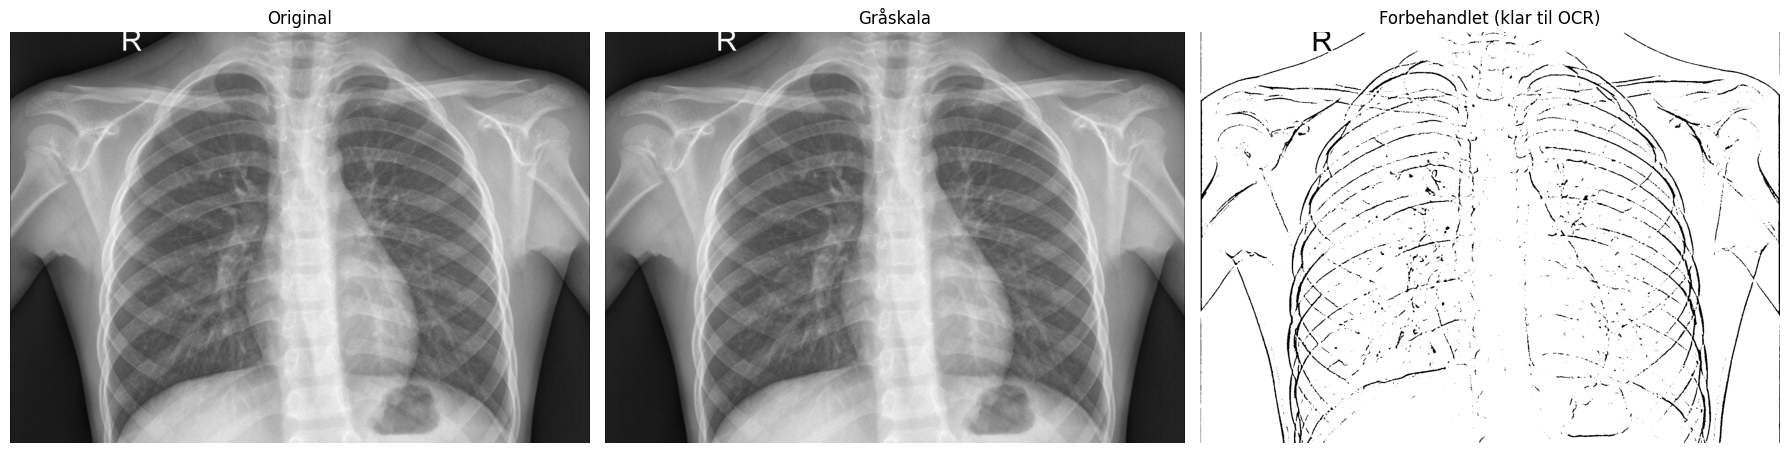

Billedstørrelse: 1857×1317 px


In [15]:
def load_and_preprocess(image_path):
    """
    Indlæser et billede og forbereder det til OCR.
    Returnerer: (original_bgr, grå, forbehandlet)
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Kunne ikke indlæse: {image_path}")

    # Gråskala
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Invert: røntgen er typisk lys tekst på sort -> gør til sort tekst på hvid
    inverted = cv2.bitwise_not(gray)

    # Fjern støj
    denoised = cv2.fastNlMeansDenoising(inverted, h=10)

    # Adaptiv thresholding – god til uens belysning
    thresh = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # Morphological åbning: fjerner små støjpunkter
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    return img_bgr, gray, cleaned


# Indlæs billedet
img_bgr, gray, preprocessed = load_and_preprocess(IMAGE_PATH)

# Vis original og forbehandlet
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Gråskala")
axes[1].axis("off")

axes[2].imshow(preprocessed, cmap="gray")
axes[2].set_title("Forbehandlet (klar til OCR)")
axes[2].axis("off")

plt.tight_layout()
plt.show()
print(f"Billedstørrelse: {img_bgr.shape[1]}×{img_bgr.shape[0]} px")

## 2. OCR - Find bogstaver og tal med valgfrit sogeomrade (ROI)

Soeger efter alle bogstaver (A-Z) og cifre (0-9) i billedet.

Skift `ROI_MODE` i cellen nedenfor: `full`, `top_band`, `top_left` eller `manual`.

In [16]:
def _get_roi_box(img_shape, roi_mode="left_half", manual_roi=None):
    """Returnerer (x1, y1, x2, y2) for sogeomradet."""
    h, w = img_shape[:2]
    if roi_mode == "full":
        return (0, 0, w, h)
    if roi_mode == "top_band":
        return (0, 0, w, int(0.45 * h))
    if roi_mode == "top_left":
        return (0, 0, int(0.38 * w), int(0.30 * h))
    if roi_mode == "left_half":
        # Hele venstre halvdel af billedet
        return (0, 0, w // 2, h)
    if roi_mode == "manual" and manual_roi is not None:
        x1, y1, x2, y2 = manual_roi
        x1 = max(0, min(int(x1), w - 1))
        y1 = max(0, min(int(y1), h - 1))
        x2 = max(x1 + 1, min(int(x2), w))
        y2 = max(y1 + 1, min(int(y2), h))
        return (x1, y1, x2, y2)
    return (0, 0, w, h)


ALL_CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789"

def detect_markers(gray_img, preprocessed_img, conf_threshold=20,
                   roi_mode="left_half", manual_roi=None, whitelist=ALL_CHARS,
                   min_size=15):
    """
    Finder bogstaver og tal via OCR med valgfri ROI og tegn-whitelist.

    min_size : minimum bredde OG hoejde (px) for en detektion.
               Filtrerer sma stoej-tegn fra. Saet hoejere (fx 20-30) for kun
               at finde store markerings-bogstaver som 'R'.
    """
    x1, y1, x2, y2 = _get_roi_box(gray_img.shape, roi_mode, manual_roi)
    roi_gray = gray_img[y1:y2, x1:x2]
    roi_inv  = cv2.bitwise_not(roi_gray)
    roi_pre  = preprocessed_img[y1:y2, x1:x2]
    _, roi_otsu = cv2.threshold(roi_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    variants = [roi_gray, roi_inv, roi_pre, roi_otsu]
    configs = [
        f"--oem 3 --psm 11 -c tessedit_char_whitelist={whitelist}",
        f"--oem 3 --psm 6  -c tessedit_char_whitelist={whitelist}",
    ]

    seen = {}
    for variant in variants:
        for cfg in configs:
            data = pytesseract.image_to_data(variant, config=cfg, output_type=pytesseract.Output.DICT)
            for i in range(len(data["text"])):
                txt = (data["text"][i] or "").strip()
                if not txt:
                    continue
                try:
                    conf = float(data["conf"][i])
                except (TypeError, ValueError):
                    conf = -1.0
                if conf < conf_threshold:
                    continue

                bx = int(data["left"][i]) + x1
                by = int(data["top"][i]) + y1
                bw = int(data["width"][i])
                bh = int(data["height"][i])

                # Filtrer for lille: begge dimensioner skal vaere >= min_size
                if bw < min_size or bh < min_size:
                    continue

                key = (round(bx / 10), round(by / 10), txt)
                if key not in seen or conf > seen[key]["conf"]:
                    seen[key] = {"text": txt, "conf": round(conf, 1),
                                 "x": bx, "y": by, "w": bw, "h": bh}

    detections = sorted(seen.values(), key=lambda d: (d["y"], d["x"]))
    return detections, (x1, y1, x2, y2)


def detect_text(preprocessed_img, conf_threshold=20, min_size=15):
    """Bagudkompatibel wrapper til mappe-scan."""
    dets, _ = detect_markers(preprocessed_img, preprocessed_img,
                              conf_threshold=conf_threshold,
                              roi_mode="full",
                              min_size=min_size)
    return dets


# --- Indstillinger ---
# ROI_MODE: full | top_band | top_left | left_half | manual
ROI_MODE      = "left_half"   # hele venstre halvdel
MANUAL_ROI    = (20, 5, 220, 120)  # bruges kun ved ROI_MODE="manual"
MIN_CHAR_SIZE = 15   # mindste tilladt bredde/hoejde i px
                     # Hojere vaerdi (fx 20-40) = kun store markerings-bogstaver

detections, roi_box = detect_markers(
    gray,
    preprocessed,
    conf_threshold=20,
    roi_mode=ROI_MODE,
    manual_roi=MANUAL_ROI,
    min_size=MIN_CHAR_SIZE,
)

print("=" * 50)
print(f"  ROI mode              : {ROI_MODE}")
print(f"  ROI box (x1,y1,x2,y2) : {roi_box}")
print(f"  Min. tegnstorrelse    : {MIN_CHAR_SIZE}px")
print(f"  Fundne tegn/ord       : {len(detections)}")
for d in detections:
    print(f"    '{d['text']}'  konf={d['conf']}%  pos=({d['x']},{d['y']})  storrelse={d['w']}x{d['h']}")
print("=" * 50)

  ROI mode              : left_half
  ROI box (x1,y1,x2,y2) : (0, 0, 928, 1317)
  Min. tegnstorrelse    : 15px
  Fundne tegn/ord       : 54
    'Re'  konf=50.0%  pos=(364,0)  storrelse=564x64
    'LE'  konf=29.0%  pos=(636,63)  storrelse=60x44
    'a'  konf=28.0%  pos=(577,66)  storrelse=60x31
    'JOP'  konf=27.0%  pos=(492,203)  storrelse=365x37
    'ER'  konf=40.0%  pos=(56,204)  storrelse=369x32
    'wt'  konf=23.0%  pos=(805,234)  storrelse=74x29
    'OOP'  konf=20.0%  pos=(475,235)  storrelse=196x27
    'a'  konf=57.0%  pos=(483,284)  storrelse=57x36
    'non'  konf=35.0%  pos=(826,291)  storrelse=44x37
    'a'  konf=44.0%  pos=(681,294)  storrelse=84x38
    'a'  konf=40.0%  pos=(69,299)  storrelse=69x28
    'SON'  konf=50.0%  pos=(175,309)  storrelse=85x30
    'a'  konf=38.0%  pos=(456,329)  storrelse=239x70
    'y'  konf=79.0%  pos=(857,337)  storrelse=31x52
    'ae'  konf=24.0%  pos=(687,390)  storrelse=66x48
    'See'  konf=48.0%  pos=(687,390)  storrelse=66x48
    'ae'  konf

## 3. Visualiser fundne tegn og tal

Tegner en grøn bounding box omkring hvert fundet tegn/ord.

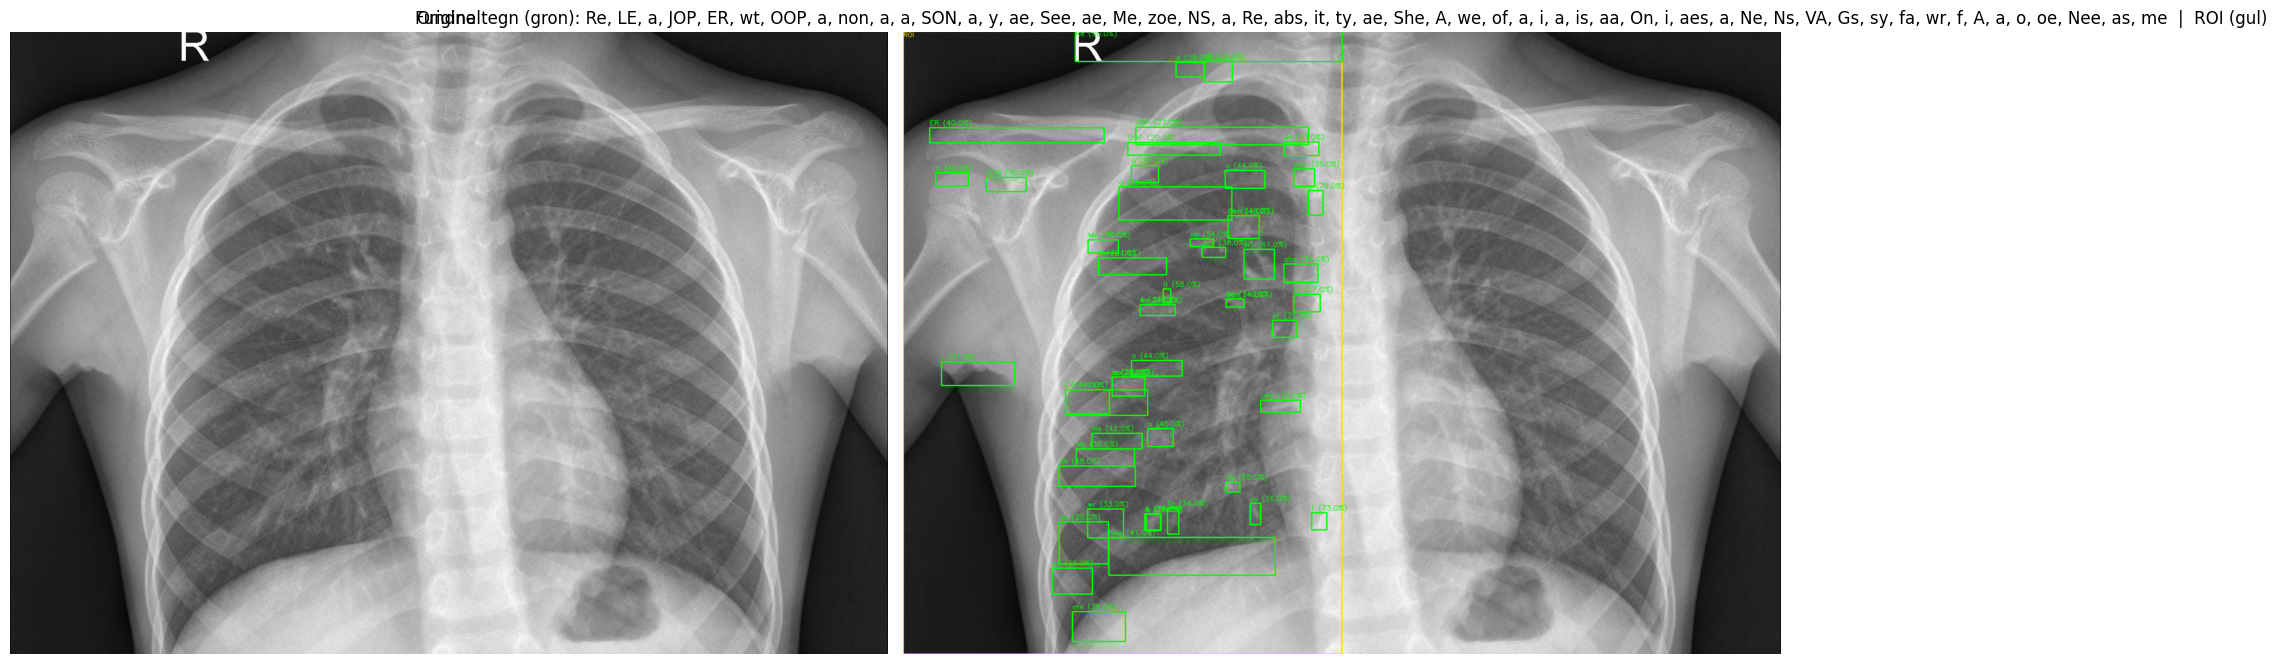

In [17]:
def draw_detections(img_bgr, detections, roi_box=None):
    """Tegner ROI (gul) og detektioner (gron) pa en kopi af billedet."""
    annotated = img_bgr.copy()

    if roi_box is not None:
        x1, y1, x2, y2 = roi_box
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 220, 255), 2)
        cv2.putText(annotated, "ROI", (x1, max(12, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 220, 255), 1, cv2.LINE_AA)

    for d in detections:
        x, y, w, h = d["x"], d["y"], d["w"], d["h"]
        cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 255, 0), 2)
        label = f"{d['text']} ({d['conf']}%)"
        cv2.putText(annotated, label, (x, max(y - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)
    return annotated


annotated_img = draw_detections(img_bgr, detections, roi_box=roi_box)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
found_txt = ", ".join(d["text"] for d in detections) if detections else "ingen"
axes[1].set_title(f"Fundne tegn (gron): {found_txt}  |  ROI (gul)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 4. Scan en hel mappe med billeder

Nyttigt når du vil processere alle billeder i Chest X-Ray datasættet på én gang og gemme resultaterne.

In [18]:
import os
import pandas as pd

BASE       = r"..\..\billeder\chest_xray"
CLASSES    = ["NORMAL", "PNEUMONIA"]
EXTENSIONS = {".png", ".jpg", ".jpeg"}
MAX_IMAGES = 10   # antal billeder per klasse

rows = []
for cls in CLASSES:
    folder = os.path.join(BASE, cls)
    files  = sorted(
        f for f in os.listdir(folder)
        if os.path.splitext(f)[1].lower() in EXTENSIONS
    )[:MAX_IMAGES]

    print(f"\n--- {cls} ({len(files)} billeder) ---")
    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            _, g, prep = load_and_preprocess(fpath)
            dets = detect_markers(g, prep, roi_mode="left_half", min_size=MIN_CHAR_SIZE)[0]

            all_text  = " ".join(d["text"] for d in dets)
            n_chars   = sum(len(d["text"]) for d in dets)
            n_letters = sum(1 for c in all_text if c.isalpha())
            n_words   = len(all_text.split())

            rows.append({
                "klasse":       cls,
                "fil":          fname,
                "tekst_blokke": len(dets),
                "ord":          n_words,
                "tegn_total":   n_chars,
                "bogstaver":    n_letters,
                "fundet_tekst": all_text.strip(),
            })
            print(f"  ✓  {fname:40s}  blokke={len(dets):3d}  tegn={n_chars:4d}  tekst={all_text.strip()!r}")
        except Exception as e:
            print(f"  ✗  {fname}  ->  {e}")

df = pd.DataFrame(rows)
print("\n\n=== Opsummering ===")
print(df.to_string(index=False))

# Gem til CSV ved siden af notebooken
output_csv = os.path.join(os.path.dirname(os.path.abspath(".")), "tekst_scanner_resultater.csv")
df.to_csv(output_csv, index=False)
print(f"\nGemt: {output_csv}")


--- NORMAL (10 billeder) ---
  ✓  IM-0001-0001.jpeg                         blokke= 54  tegn= 101  tekst='Re LE a JOP ER wt OOP a non a a SON a y ae See ae Me zoe NS a Re abs it ty ae She A we of a i a is aa On i aes a Ne Ns VA Gs sy fa wr f A a o oe Nee as me'
  ✓  IM-0003-0001.jpeg                         blokke= 54  tegn= 119  tekst='a a set a Ao Ae ee Lee ee eed Le wee kn ca tei ee 4 a ee Se Sere kets pwr cies a 4 a i Le a ler ee aad a Veo wif 2 og oe gi Pig Pigg em KE ee eee Paseo a awe re a ind Af ly'
  ✓  IM-0005-0001.jpeg                         blokke= 86  tegn= 182  tekst='R NS Ste ee 7S Se a ow a ty att 7 va foe en ae if LA ot ae f ra ms Nee oF Bet ent aaa whee i fo we foe eee NL es aes ce at Re 2 af fm aft oN ma aoa om wee pt 7 aft can woe ae x mA NO ee aN at Bae be ir yd oa x Pa aw a aN oN at af a 4a vy oe if Pe re ay Bee Fee Tae fs'
  ✓  IM-0006-0001.jpeg                         blokke= 42  tegn=  91  tekst='SS i ia we a St XO Ma ee Nok oN ie ae ata Soa ane a wes Cannel 